









































# Custom CNN - Emotion Detection (FER-2013) - fixed

Note on the name: this file was originally called `resnet50v2.ipynb` but never
actually used ResNet50V2 - it's a custom CNN trained from scratch. Keeping that
straight matters for your discussion, so this version is honest about what it is.

## What was fixed from the original

1. **Validation/test leak (the big one).** The original passed `test_data`
   straight in as `validation_data`, and `EarlyStopping` / `ModelCheckpoint`
   both watched that same set. That means the checkpoint and stopping point
   were chosen *using* the test set - so the final "test accuracy" wasn't a
   fair unseen-data number. Fixed by carving a real validation split out of
   `train/` and touching `test/` only once, at the very end.
2. **No random seeds** -> added, for reproducibility.
3. **Class weights were computed but not consistently used** -> now always
   passed into `.fit()`.
4. **Removed the CNN+LSTM hybrid models.** Reshaping a conv feature map into
   "timesteps" for an LSTM is hard to justify for a static image (LSTMs are
   built for real sequential data) and it roughly doubled training time for
   a debatable gain. Cutting it keeps this simpler to defend.
5. Added markdown explanations throughout, so each design choice has a
   one-line "why" you can say out loud in discussion.

## 0. Colab setup - get the dataset from Kaggle

This notebook was written for Kaggle's environment (`/kaggle/input/...`), which doesn't exist on Colab. To get the same FER-2013 data here, we use the **Kaggle API** with your `kaggle.json` credentials file:

1. Go to https://www.kaggle.com/settings/account -> **API** -> **Create New Token**. This downloads a `kaggle.json` file to your computer.
2. Run the cell below and click **Choose Files** when prompted, then upload that `kaggle.json`.
3. The next cell downloads and unzips the `fer2013` dataset into `/content/fer2013`.

Your `kaggle.json` is only used locally in this Colab session - it is not saved anywhere else.

In [8]:
from google.colab import files
import os

# upload the kaggle.json you downloaded from kaggle.com/settings/account
uploaded = files.upload()  # pick kaggle.json in the dialog

assert 'kaggle.json' in uploaded, "Please upload a file named exactly 'kaggle.json'"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])

# kaggle's API refuses to run unless this file is private
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('kaggle.json installed.')

Saving kaggle.json to kaggle.json
kaggle.json installed.


In [9]:
# ============================================================
# COLAB - FER-2013 DATASET SETUP
# ============================================================

!pip -q install kaggle

import os
import glob

# ------------------------------------------------------------
# Download and extract FER-2013 directly into /content
# ------------------------------------------------------------

!kaggle datasets download \
    -d msambare/fer2013 \
    -p /content \
    --unzip

print("\nContents of /content:")
print(os.listdir("/content"))


# ------------------------------------------------------------
# Find train/ and test/ automatically
# ------------------------------------------------------------

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/content"):

    folder = os.path.basename(root).lower()

    if folder == "train" and train_dir is None:
        train_dir = root

    elif folder == "test" and test_dir is None:
        test_dir = root


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET PATHS")
print("=" * 60)

print("Train:", train_dir)
print("Test :", test_dir)

if train_dir is None:
    raise FileNotFoundError(
        " Could not find train/ folder."
    )

if test_dir is None:
    raise FileNotFoundError(
        "Could not find test/ folder."
    )

print("\nTrain classes:")
print(sorted(os.listdir(train_dir)))

print("\nTest classes:")
print(sorted(os.listdir(test_dir)))

print("\n✅ FER-2013 READY!")

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:03<00:00, 16.2MB/s]


Contents of /content:
['.config', 'test', 'kaggle.json', '.ipynb_checkpoints', 'train', 'models', 'sample_data']

DATASET PATHS
Train: /content/train
Test : /content/test

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

✅ FER-2013 READY!


## 1. Setup

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# fix random seeds so results are reproducible run to run
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

os.makedirs('/content/models', exist_ok=True)

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
import os

# FER-2013 was extracted directly into /content
dataset_path = "/content"

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Train Path:", train_dir)
print("Test Path:", test_dir)

# Verify
assert os.path.isdir(train_dir), f"Train folder not found: {train_dir}"
assert os.path.isdir(test_dir), f"Test folder not found: {test_dir}"

print("\nDataset found!")

print("\nTrain classes:")
print(sorted(os.listdir(train_dir)))

print("\nTest classes:")
print(sorted(os.listdir(test_dir)))

Train Path: /content/train
Test Path: /content/test

Dataset found!

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 2. Build the data pipelines

**The fix is here:** `train_datagen` now uses `validation_split=0.1`, so 10% of
the *training* folder is held back as a validation set. `EarlyStopping` and
`ModelCheckpoint` will watch that split - never the real test set. `test_dir`
is loaded separately and is only used once, at the very end, for the number
we actually report.

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,       # paper mentions rotation
    horizontal_flip=True,    # paper mentions image flipping
    fill_mode='nearest',
    validation_split=0.1,    # carve out a real validation set from train/
)

test_datagen = ImageDataGenerator(rescale=1./255)

# grayscale & 48x48 target size
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

# held out completely separate - only touched once, at final evaluation
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
)

print('class order:', train_data.class_indices)
print('train batches:', len(train_data), '| val batches:', len(val_data), '| test batches:', len(test_data))

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
class order: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
train batches: 404 | val batches: 45 | test batches: 113


In [13]:
# the classes are imbalanced (disgust is rare, happy is common), so we give
# rare emotions bigger weights during training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes,
)
class_weight_dict = dict(enumerate(class_weights))

class_names = list(train_data.class_indices.keys())
for i, w in class_weight_dict.items():
    print(f'{class_names[i]:>8}: weight = {w:.2f}')

   angry: weight = 1.03
 disgust: weight = 9.39
    fear: weight = 1.00
   happy: weight = 0.57
 neutral: weight = 0.83
     sad: weight = 0.85
surprise: weight = 1.29


## 3. Build the model

A custom CNN trained from scratch: 4 convolutional blocks (32 -> 64 -> 128 ->
256 filters), each with BatchNorm + ReLU + MaxPooling + Dropout, then two
dense layers before the final 7-way softmax. This matches the architecture
style described in several FER-2013 papers.

In [14]:
model = Sequential()

# --- 1st convolutional block (32 filters) ---
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- 2nd convolutional block (64 filters) ---
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- 3rd convolutional block (128 filters) ---
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- 4th convolutional block (256 filters) ---
model.add(Conv2D(256, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(256, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# --- flatten & fully connected layers ---
model.add(Flatten())

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.50))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.50))

# --- output layer (7 emotions) ---
model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # label smoothing makes the model a little less overconfident -> generalizes better
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             

 Total params: 1,328,167 (5.07 MB)

 Trainable params: 1,325,991 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

## 4. Train

In [15]:
CHECKPOINT = '/content/models/emotion_cnn_fixed.keras'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        CHECKPOINT,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
]

epochs = 150   # early stopping will almost certainly cut this short

history = model.fit(
    train_data,
    validation_data=val_data,     # <- validation split, NOT the test set
    epochs=epochs,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/150
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1525 - loss: 2.2386
Epoch 1: val_accuracy improved from None to 0.06520, saving model to /content/models/emotion_cnn_fixed.keras

Epoch 1: finished saving model to /content/models/emotion_cnn_fixed.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.1479 - loss: 2.1375 - val_accuracy: 0.0652 - val_loss: 1.9622 - learning_rate: 0.0010
Epoch 2/150
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1540 - loss: 1.9997
Epoch 2: val_accuracy improved from 0.06520 to 0.19596, saving model to /content/models/emotion_cnn_fixed.keras

Epoch 2: finished saving model to /content/models/emotion_cnn_fixed.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.1624 - loss: 1.9601 - val_accuracy: 0.1960 - val_loss: 1.8719 - learning_rate: 0.0010
Epoch 3/150
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1989 - loss: 1.8841
Epoch 3: val_accuracy did not improve from 0.19596
404/404 ━━━━━━━━━━━━━━━━━━━━

## 5. Evaluate - on the held-out `test/` folder, touched here for the first time

This is the only place `test_data` is used. Because it played no role in
choosing the checkpoint or the stopping point, this number is a fair estimate
of how the model would do on new, unseen photos.

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6662 - loss: 1.1721

Final TEST accuracy (never seen during training or model selection): 66.62%



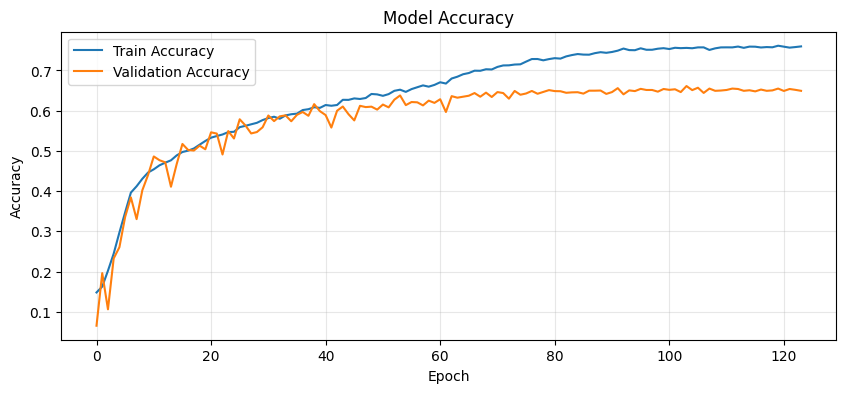

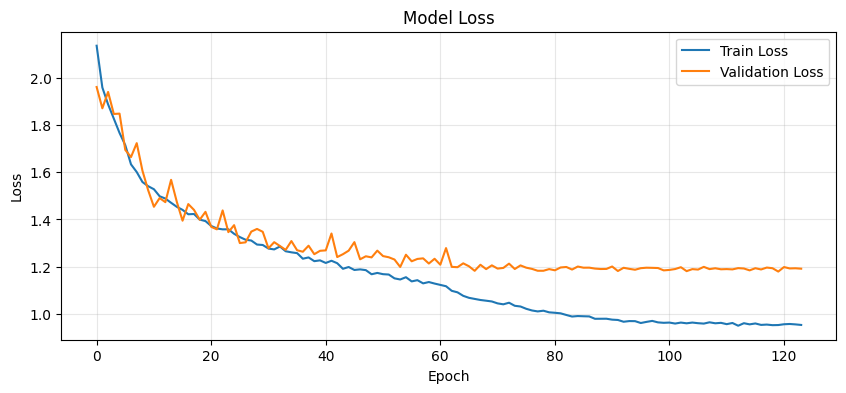

In [16]:
best_model = tf.keras.models.load_model(CHECKPOINT)

loss, accuracy = best_model.evaluate(test_data)
print(f"\nFinal TEST accuracy (never seen during training or model selection): {accuracy * 100:.2f}%\n")

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
Classification Report:

              precision    recall  f1-score   support

       angry       0.58      0.62      0.60       958
     disgust       0.65      0.69      0.67       111
        fear       0.55      0.42      0.48      1024
       happy       0.89      0.84      0.86      1774
     neutral       0.57      0.68      0.62      1233
         sad       0.55      0.53      0.54      1247
    surprise       0.75      0.84      0.79       831

    accuracy                           0.67      7178
   macro avg       0.65      0.66      0.65      7178
weighted avg       0.67      0.67      0.66      7178



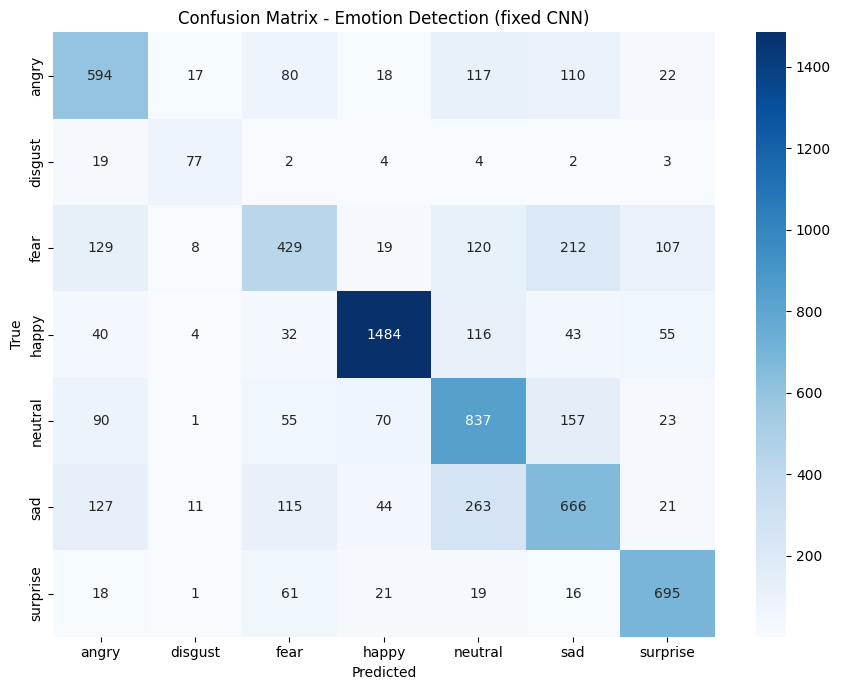

In [17]:
test_data.reset()

predictions = best_model.predict(test_data)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Emotion Detection (fixed CNN)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 6. Discussion points

- **Why fix the validation split?** Using the test set for early stopping and
  checkpoint selection lets the model indirectly "see" it, inflating the
  reported accuracy. Keeping a separate validation split (from `train/`) and
  touching `test/` only once gives an honest, defensible number.
- **Why class weights?** FER-2013 is imbalanced (disgust is rare, happy is
  common) - without weights the model would just ignore rare emotions to
  minimize average loss.
- **Why label smoothing?** Makes the model less overconfident on borderline
  images, which helps generalization on a dataset with known label noise.
- **Why drop the LSTM branch from the earlier version?** LSTMs model
  sequential dependencies; there isn't a strong reason a static image's
  spatial layout should be treated as a time sequence, and it roughly doubled
  training cost for an unclear gain.
- **Expected accuracy:** FER-2013 is grayscale, 48x48, and known to be noisy -
  published work reports human agreement on this dataset is only around
  65-70%, so that's the realistic ceiling for a single model here, not 90%+.

## Notebook Summary
This notebook implements a Convolutional Neural Network (CNN) for emotion detection. It fixes earlier issues and simplifies the architecture by removing the CNN+LSTM hybrid approach, which is not ideal for static images and takes too long to train. The model is trained on the FER-2013 dataset. It focuses on a more standard and reliable CNN architecture for emotion classification.
